In [1]:
import numpy as np
import xarray as xr
from matplotlib import pyplot as plt
import pandas as pd
from fonts_config import set_computer_modern, truncate_colormap
set_computer_modern()
import matplotlib as mpl
mpl.rcParams['axes.unicode_minus'] = False
from matplotlib.patches import Rectangle
import string
from scipy.stats import gaussian_kde
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

In [2]:
LGM = xr.open_dataset("../output/LGM_ens.nc")
hol = xr.open_dataset("../output/HTM_ens.nc")

n_best = 2572
scores = xr.open_dataset("../scoring/scores/scores_final.nc")

In [3]:
# ----------------------------------------------------------------------------
# Paths
# ----------------------------------------------------------------------------

labels  = ["Clark & Mix (2002)", "Huybrechts (2002)", "Flemming & Lambeck (2004)", "local LGM Simpson et al. (2009)", "LGM Simpson et al. (2009)","local Lecavalier et al. (2014)",
           "Lecavalier et al. (2014)","Bradley et al. (2018)","Buizert et al. (2018)", "Tabone et al. (2018)", "Quiquet et al. (2021)","local LGM Leger et al. (2025)"]
V_sle = [2.5, 2.7, 3.1, 4.6, 4.1, 5.1, 4.7, 2.59, (3.1+4.5)/2, (5.3+4.6)/2, 2.6, (7.5+6)/2]
err   = [0.5, 0.8, 0,   0,   0,   0,   0,   0, (-3.1+4.5)/2,(5.3-4.6)/2, 0, (7.5-6)/2]

ds_lgm = xr.Dataset(
    data_vars={
        "V_sle": (["sim"], V_sle, {"units": "m", "long_name": "Sea Level Equivalent"}),
        "error": (["sim"], err, {"units": "m", "long_name": "Uncertainty"})
    },
    coords={
        "sim": list(range(len(V_sle))),   
        "label": (["sim"], labels)})


In [4]:
# ----------------------------------------------------------------------------
# Paths
# ----------------------------------------------------------------------------

labels  = ["Simpson et al. (2009)", "Lecavalier et al. (2014)","Buizert et al. (2018)", "Nielsen et al. (2018)", "Yang et al. (2022)"]
HTM_sle = [-0.17, -0.16, -0.55/2, -(0.15+1.2)/2, -0.2]
err   = [0,   0,     0.55/2,    (-0.15+1.2)/2, 0]

ds_hol = xr.Dataset(
    data_vars={
        "V_sle": (["sim"], HTM_sle, {"units": "m", "long_name": "Sea Level Equivalent"}),
        "error": (["sim"], err, {"units": "m", "long_name": "Uncertainty"})
    },
    coords={
        "sim": list(range(len(HTM_sle))),   
        "label": (["sim"], labels)})


<>:90: SyntaxWarning: invalid escape sequence '\D'
<>:90: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_212897/1203541635.py:90: SyntaxWarning: invalid escape sequence '\D'
  ax.set(ylabel=f'{era} $\Delta$GMSL (m)')


Results LGM:
  Best sim: -5.75
  Rango 68% (Prob. Accum): [-6.31, -3.93]
  Rango 95% (Prob. Accum): [-6.31, -3.57]
Results HTM:
  Best sim: 0.45
  Rango 68% (Prob. Accum): [0.43, 1.18]
  Rango 95% (Prob. Accum): [0.40, 1.23]


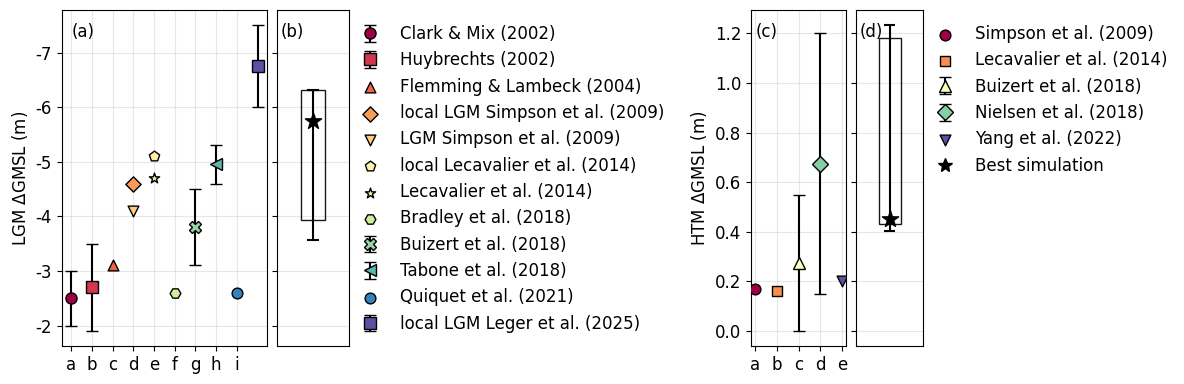

In [ ]:

def plot_uncertainty_accumulation_box2(ax, df_vals, weights, y_best):
    temp_df = pd.DataFrame({'val': df_vals, 'w': weights})
    temp_df = temp_df.sort_values(by='w', ascending=False).reset_index(drop=True)
    temp_df['cum_w'] = temp_df['w'].cumsum() / temp_df['w'].sum()

    top_68 = temp_df[temp_df['cum_w'] <= 0.68]
    if top_68.empty: top_68 = temp_df.head(1)
    r68_min, r68_max = top_68['val'].min(), top_68['val'].max()

    top_95 = temp_df[temp_df['cum_w'] <= 0.95]
    r95_min, r95_max = top_95['val'].min(), top_95['val'].max()

    ax.vlines(0, r95_min, r95_max, color='black', linestyle='-', lw=1.5)
    ax.hlines([r95_min, r95_max], xmin=-0.1, xmax=0.1, color='black', lw=1.5)

    box_width = 0.4
    rect = Rectangle((-box_width/2, r68_min), box_width, r68_max - r68_min, 
                     facecolor="none", edgecolor='black', zorder=3, alpha=0.9)
    ax.add_patch(rect)
    ax.scatter(0, y_best, color='black', edgecolor='black', marker='*', s=150, zorder=5, label='Best Sim')
    ax.set_xlim(-0.6, 0.6)
    ax.set_xticks([])
    return r68_min, r68_max, r95_min, r95_max
    
def plot_compare_lgm3(ax, ds, df, vols, n_best, era,label):
    mks = ['o', 's', '^', 'D', 'v', 'p', '*', 'H', 'X', '<']
    letters = list(string.ascii_lowercase)
    cmap = plt.get_cmap('Spectral')
    n = len(ds.sim)
    h_list, l_list = [], []
    j = 0
    
    for i, s_id in enumerate(ds.sim.values):
        d = ds.sel(sim=s_id)
        c = cmap(i / (n - 1)) if n > 1 else cmap(0.5) 
        m = mks[i % len(mks)]
        label_str = str(d.label.values.item())
        
        if d.error == 0:
            h = ax.scatter(j, -d.V_sle, marker=m, color=c, s=60, edgecolors='black', zorder=5)
        else:
            h = ax.errorbar(j, -d.V_sle, yerr=d.error, fmt=m, color=c, markersize=8, 
                           markeredgecolor='black', ecolor='black', capsize=4, zorder=5)
        
        h_list.append(h)
        l_list.append(label_str)
        
        if "local" not in label_str.lower():
            j += 1

    divider = make_axes_locatable(ax)
    if era == "LGM":
        size_violin="35%"
        pad_leg = 1.35
    else:
        size_violin="70%"
        pad_leg = 1.7
    ax_violin = divider.append_axes("right", size=size_violin, pad=0.1, sharey=ax)
    
    df_resampled = df.sample(n=3000, replace=True, weights='weight')
    y_best = -vols.dV_sle.sel(sim=n_best).values

    # --- Print results ---
    r68_low, r68_high, r95_low, r95_high = plot_uncertainty_accumulation_box2(
        ax_violin, df.data.values, df.weight.values, y_best)
    
    print(f"Results {era}:")
    print(f"  Best sim: {y_best:.2f}")
    print(f"  Rango 68% (Prob. Accum): [{r68_low:.2f}, {r68_high:.2f}]")
    print(f"  Rango 95% (Prob. Accum): [{r95_low:.2f}, {r95_high:.2f}]")

    ax_violin.set_xlabel("")
    ax_violin.set_ylabel("")
    ax_violin.grid(axis='both', alpha=0.3)
    plt.setp(ax_violin.get_yticklabels(), visible=False) 

    if era == "LGM":
        ax.invert_yaxis()

    # Leyenda 
    if era == "HTM":
        proxy_best = Line2D([0], [0], marker='*', color='w', markerfacecolor='black', 
                    markeredgecolor='black', markersize=10)
        h_list.extend([proxy_best])
        l_list.extend([f'Best simulation'])
    
    ax.legend(h_list, l_list, bbox_to_anchor=(pad_leg, 1), loc='upper left', frameon=False)
    ax.set_xticks(range(j))
    ax.set_xticklabels(letters[:j])
    ax.set(ylabel=f'{era} $\Delta$GMSL (m)')
    ax.grid(axis='both', alpha=0.3)

    ax.text(0.05, 0.92, label[0], transform=ax.transAxes)
    ax_violin.text(0.05, 0.92, label[1], transform=ax_violin.transAxes,zorder=1)

    return

data = -LGM.dV_sle.values.flatten()
sco = scores.S.values / scores.S.values.sum()
df1 = pd.DataFrame({'data': data, 'weight': scores.S.values})

kde = gaussian_kde(data, weights=sco)
y_range1 = np.linspace(min(data), max(data), 100)
v_density1 = kde(y_range1)

data = -hol.dV_sle.values.flatten()
sco = scores.S.values / scores.S.values.sum()
kde = gaussian_kde(data, weights=sco)
y_range2 = np.linspace(min(data), max(data), 100)
v_density2 = kde(y_range2)
df2 = pd.DataFrame({'data': data, 'weight': scores.S.values})

fig, ax = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [5, 3]})

plot_compare_lgm3(ax[0], ds_lgm, df1, LGM, n_best, "LGM",label=["(a)","(b)"])
plot_compare_lgm3(ax[1], ds_hol, df2, hol, n_best, "HTM",label=["(c)","(d)"])


plt.tight_layout()
plt.savefig(f"../figs_final/fig14_{n_best}_compare_lgm_hol.pdf", dpi=300)